In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('19-heart.csv')

In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [7]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [8]:
df.target.value_counts()

target
1    165
0    138
Name: count, dtype: int64

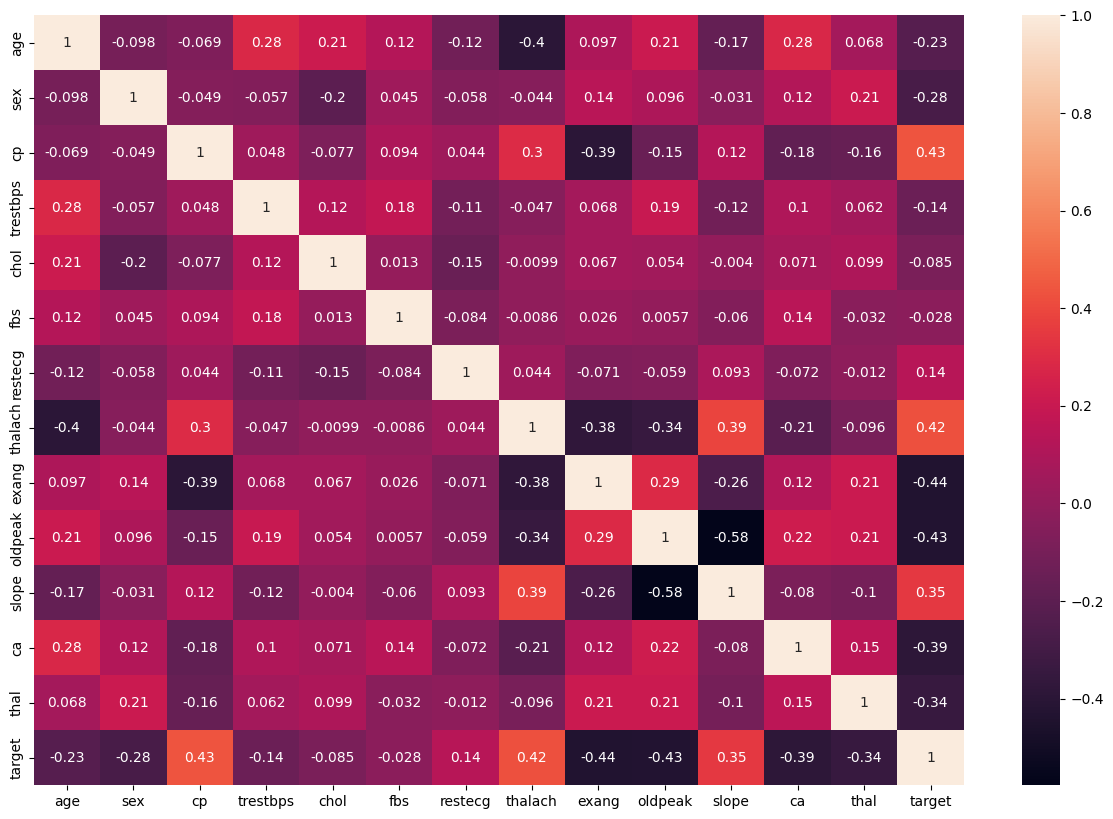

In [11]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(),annot=True)
plt.show()

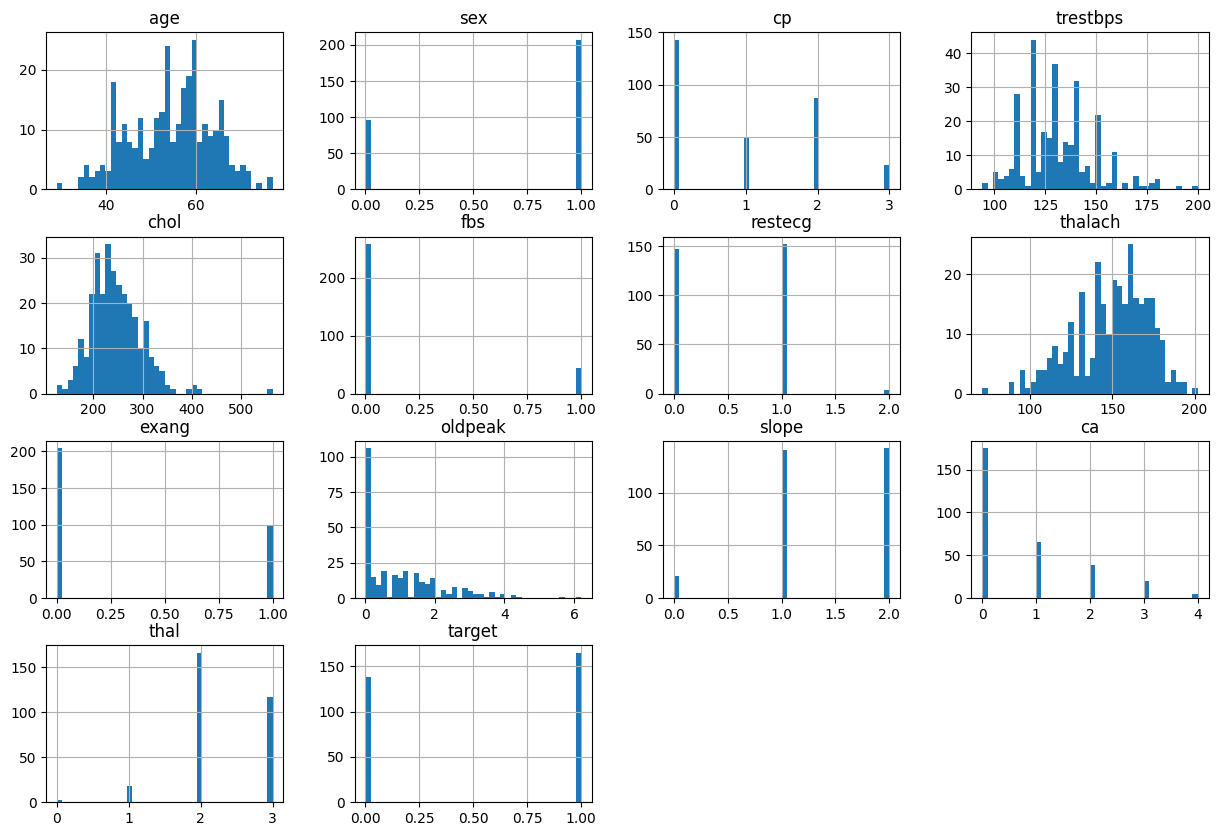

In [12]:
#paylanmalar
df.hist(bins=40,figsize=(15,10))
plt.show()

In [14]:
X = df.drop('target',axis = 1)
y = df.target

In [15]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=15)

In [16]:
def correlation_for_dropping(df, threshold):
    columns_to_drop = set()
    corr = df.corr()
    for i in range(len(corr.columns)):
        for j in range(i):
            if abs(corr.iloc[i, j]) > threshold:
                colname = corr.columns[i]
                columns_to_drop.add(colname)
    return columns_to_drop

In [17]:
correlation_for_dropping(X_train,0.85)

set()

In [18]:
 
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

from sklearn.ensemble import GradientBoostingClassifier

# Gradient Boosting Classifier Parametrləri Cheat Sheet
gbc_model = GradientBoostingClassifier(
    # --- BOOSTING (GÜCLƏNDİRMƏ) VƏ İTKİ PARAMETRLƏRİ ---
    
    # 1. loss (Default: 'log_loss')
    # Optimallaşdırılacaq itki funksiyası.
    # - 'log_loss': Ehtimallara (probabilities) əsaslanan klassik Logistik Reqressiya itkisidir. 
    #   Demək olar ki, həmişə ən yaxşı seçimdir (xüsusən çoxsınıflı - multiclass təsnifatda).
    # - 'exponential': Bunu seçsəniz, model AdaBoost alqoritminin məntiqi ilə işləyir.
    loss='log_loss',

    # 2. learning_rate (Default: 0.1)
    # Hər yeni ağacın əvvəlki səhvləri düzəltmək üçün atdığı "addımın böyüklüyü".
    # - Aşağı dəyərlər (məs: 0.01 və ya 0.05) modeli daha stabil edir (overfitting-i azaldır), 
    #   amma n_estimators-u artırmağı tələb edir.
    learning_rate=0.1,

    # 3. n_estimators (Default: 100)
    # Qurulacaq ağacların (mərhələlərin) ümumi sayı.
    # - Modelin öyrənmə tutumunu artırır. Amma classification-da çox böyük rəqəmlər 
    #   datanı əzbərləməyə səbəb ola bilər. Early stopping (aşağıda) ilə tənzimlənməlidir.
    n_estimators=100,

    # 4. subsample (Default: 1.0)
    # Hər ağacı öyrədərkən datanın hansı faizinin (təsadüfi olaraq) istifadə ediləcəyi.
    # - 0.8 yazsanız, Stochastic Gradient Boosting olur. Bu həm sürəti artırır, 
    #   həm də modelin fərqli senarilərə hazır olmasını (variance-ı azaltmağı) təmin edir.
    subsample=1.0,

    # --- AĞAC (TREE) STRUKTURU PARAMETRLƏRİ ---

    # 5. criterion (Default: 'friedman_mse')
    # Bölünmənin keyfiyyətini ölçən meyar. 
    # 'friedman_mse' standart MSE-yə xüsusi düzəlişlər edərək daha yaxşı nəticə verir. Dəyişməyə ehtiyac yoxdur.
    criterion='friedman_mse',

    # 6. max_depth (Default: 3)
    # Hər bir ağacın maksimum dərinliyi. 
    # - GBC-də ağaclar mütləq "dayaz" olmalıdır (adətən 3-5 arası). 
    #   Dərin ağaclar sürətlə overfitting-ə gətirib çıxarır.
    max_depth=3,

    # 7. min_samples_split (Default: 2) & min_samples_leaf (Default: 1)
    # Düyünlərin bölünməsi və yarpaqların yaranması üçün minimum sətir sayı.
    # - Datan çoxdursa, overfitting-dən qorunmaq üçün bu rəqəmləri bir az artırmaq olar (məs: 5 və 2).
    min_samples_split=2,
    min_samples_leaf=1,

    # 8. max_features (Default: None)
    # Bölünmə apararkən təsadüfi seçiləcək sütunların (feature) sayı.
    # - Sütun sayın çoxdursa, 'sqrt' və ya 'log2' etmək ağaclar arasında fərqliliyi 
    #   (diversity) artırır və performansı yaxşılaşdırır.
    max_features=None,

    # --- OVERFITTING-Ə QARŞI ERKƏN DAYANDIRMA (EARLY STOPPING) ---

    # 9. validation_fraction (Default: 0.1)
    # Early stopping üçün datanın neçə faizinin (məs: 10%) test kimi kənara qoyulacağı.
    validation_fraction=0.1,

    # 10. n_iter_no_change (Default: None)
    # Model neçə ağac ard-arda inkişaf etməsə öyrənməni dayandırsın?
    # - Mütləq istifadə edin! (Məsələn: 10). Bu, n_estimators=1000 versəniz belə, 
    #   modelin lazımsız yerə öyrənməsinin (əzbərləməsinin) qarşısını alır.
    n_iter_no_change=10,

    # 11. tol (Default: 0.0001)
    # Nə qədərlik bir inkişaf "inkişaf" sayılır? (Tolerantlıq).
    tol=0.0001,

    # --- DİGƏR ---

    # 12. warm_start (Default: False)
    # True edilsə, modeli əvvəlki öyrəndiklərinin (fit) üzərindən əlavə ağaclarla öyrətməyə davam etməyə imkan verir.
    warm_start=False,

    # 13. init (Default: None)
    # Başlanğıc təxminlər üçün istifadə olunan model. Default olaraq siniflərin paylanma tezliyinə baxır.
    init=None,

    # 14. random_state
    # Hər dəfə eyni nəticəni (reproducibility) almaq üçün sabit rəqəm.
    random_state=42,
    
    verbose=0 # 1 edərək prosesi terminalda canlı izləyə bilərsiniz
)

In [19]:
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [20]:
y_pred = gb.predict(X_test)
print(classification_report(y_pred, y_test))
print(confusion_matrix(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.82      0.74      0.78        31
           1       0.76      0.83      0.79        30

    accuracy                           0.79        61
   macro avg       0.79      0.79      0.79        61
weighted avg       0.79      0.79      0.79        61

[[23  8]
 [ 5 25]]


In [23]:
#hyperparameter tuning
parameters = {
        "loss" : ['log_loss', 'exponential'],
        "learning_rate" : [0.01, 0.05, 0.1],
        "n_estimators" : [100, 150, 180, 200],
        "max_depth" : [3,4,5],
        "subsample" : [0.8, 1.0]
}

In [24]:
grid_search = GridSearchCV(estimator=GradientBoostingClassifier(), param_grid = parameters, cv = 5, n_jobs = -1, verbose=1)

In [25]:

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 144 candidates, totalling 720 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoostingClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'loss': ['log_loss', 'exponential'], 'max_depth': [3, 4, ...], 'n_estimators': [100, 150, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold a

In [26]:
grid_search.best_params_

{'learning_rate': 0.01,
 'loss': 'log_loss',
 'max_depth': 3,
 'n_estimators': 200,
 'subsample': 0.8}

In [27]:
y_pred = grid_search.predict(X_test)
print(classification_report(y_pred, y_test))
print(confusion_matrix(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.89      0.76      0.82        33
           1       0.76      0.89      0.82        28

    accuracy                           0.82        61
   macro avg       0.83      0.83      0.82        61
weighted avg       0.83      0.82      0.82        61

[[25  8]
 [ 3 25]]
